# Problem Statement

## Objective
An e-commerce company wants to predict whether a customer visiting their website will complete a purchase during their browsing session. Understanding customer behavior and purchase intent is crucial for optimizing marketing strategies, improving user experience, and increasing conversion rates.

## Dataset
The dataset contains information about customer browsing sessions on an e-commerce website. Each row represents a single browsing session with various metrics about page visits, user behavior, and session characteristics.

## List of Attributes

| Attribute | Description |
| :--- | :--- |
| **ProductPageTime** | Total time spent on product pages (in seconds) |
| **BounceRate** | Bounce rate for the pages visited (percentage of single-page sessions) |
| **ExitRate** | Exit rate for the pages visited (percentage of exits from specific pages) |
| **PageValue** | Average value of the pages visited before completing a transaction, in tracking e-commerce transactions, also used in Google Web analytics |
| **SpecialDayProximity** | Closeness of the visit date to a special day (e.g., holidays) |
| **GeographicRegion** | Geographic region of the visitor |
| **TrafficSource** | Type of traffic source (e.g., direct, referral, social media) |
| **CustomerType** | Type of visitor (new visitor, returning visitor, etc.) |
| **PurchaseCompleted** | Target variable: Whether the visitor made a purchase (True/False) |

# Load Data

In [160]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [ ]:
# Connect to database
conn = sqlite3.connect("data/online_shopping.db")
cursor = conn.cursor()

# List tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
cursor.fetchall()

[('online_shopping',)]

In [ ]:
# Load data into DataFrame
df = pd.read_sql_query("SELECT * FROM online_shopping", conn)
df

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
0,Returning_Visitor,0.0,0.200000,0.000000,1.0,1,0.200000,0.000000,0
1,Returning_Visitor,0.0,0.100000,0.000000,2.0,1,0.000000,64.000000,0
2,Returning_Visitor,NaN,0.200000,0.000000,3.0,-9,0.200000,0.000000,0
3,Returning_Visitor,0.0,0.140000,0.000000,4.0,2,0.050000,2.666667,0
4,Returning_Visitor,0.0,NaN,NaN,4.0,1,0.020000,627.500000,0
...,...,...,...,...,...,...,...,...,...
12325,Returning_Visitor,0.0,0.029031,12.241717,NaN,1,0.007143,1783.791667,0
12326,Returning_Visitor,0.0,0.021333,NaN,8.0,1,0.000000,465.750000,0
12327,Returning_Visitor,0.0,0.086667,0.000000,13.0,1,0.083333,184.250000,0
12328,returning_Visitor,0.0,0.021053,0.000000,11.0,3,0.000000,346.000000,0


In [344]:
# Save raw data to CSV
df.to_csv("data/online_shopping_raw.csv", index=False)

# EDA

In [ ]:
# pd.set_option("display.max_colwidth", None)
# pd.reset_option("display.max_colwidth")
# pd.set_option("display.max_rows", None)
# pd.reset_option("display.max_rows")

In [ ]:
# Check nulls and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerType         12330 non-null  str    
 1   SpecialDayProximity  11714 non-null  float64
 2   ExitRate             11714 non-null  float64
 3   PageValue            11714 non-null  float64
 4   TrafficSource        11714 non-null  float64
 5   GeographicRegion     12330 non-null  int64  
 6   BounceRate           12330 non-null  float64
 7   ProductPageTime      11714 non-null  float64
 8   PurchaseCompleted    12330 non-null  int64  
dtypes: float64(6), int64(2), str(1)
memory usage: 867.1 KB


**Observations**
- Same number of null values in multiple columns (616), suggesting systematic data quality issues - possibly originating from the same data collection/ETL failure. To check.
- TrafficSource in float instead of string / int (supposed to stand for: direct, referral, social media, etc). To check.

In [14]:
# Statistical summary
df.describe(include="all")

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
count,12330,11714.000000,11714.000000,11714.000000,11714.000000,12330.000000,12330.000000,11714.000000,12330.000000
unique,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Returning_Visitor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,10022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.060833,0.043058,5.906249,4.059501,2.840308,0.020024,1198.698632,0.154745
std,NaN,0.197459,0.048506,18.682351,4.015758,2.757959,0.049423,1928.871645,0.361676
min,NaN,0.000000,0.000000,0.000000,1.000000,-9.000000,-0.200000,-52.500000,0.000000
25%,NaN,0.000000,0.014286,0.000000,2.000000,1.000000,0.000000,184.270833,0.000000
50%,NaN,0.000000,0.025286,0.000000,2.000000,2.000000,0.001961,602.958333,0.000000
75%,NaN,0.000000,0.050000,0.000000,4.000000,4.000000,0.015625,1465.955181,0.000000


**Observations**
- CustomerType: 8 unique values, with majority being "Returning_Visitor".
- ExitRate, BounceRate: max values of 0.20 and mean values of ~0.02-0.04 seems low (much better than typical) based on typical definitions and rates. Possibly pre-scaled. To check.
    - Exit rate of 0.20-0.40 is considered good for e-commerce. Definition: Total exits from a page / Total views of the page.
    - Bounce rate: 0.20-0.45 is considered a good, 0.40-0.60 is average. Definition: Total Single-Page Sessions / Total Sessions.
- GeographicRegion, BounceRate, ProductPageTime: min values are negative. May need to inpute / delete. To check.
- PurchaseCompleted has mean ~0.15 - moderate class imbalance.

### Value Counts

To identify unusual values, data types, and obvious outliers.

In [51]:
df.CustomerType.value_counts()

CustomerType
Returning_Visitor    10022
New_Visitor           1605
                       166
nan                    153
None                   153
Unknown                144
Other                   83
returning_Visitor        4
Name: count, dtype: int64

In [ ]:
# Check "returning_Visitor" entries which appear to be a typo for "Returning_Visitor"
df[df.CustomerType == "returning_Visitor"]

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
12275,returning_Visitor,0.0,0.013492,0.0,6.0,9,0.009524,2001.833333,0
12294,returning_Visitor,0.0,0.049275,0.0,1.0,7,0.017391,1422.850000,0
12316,returning_Visitor,0.0,0.036364,0.0,1.0,3,0.013636,615.000000,0
12328,returning_Visitor,0.0,0.021053,0.0,11.0,3,0.000000,346.000000,0


In [ ]:
# Check samples of remaining classes 
df[(df.CustomerType != "Returning_Visitor") & (df.CustomerType != "New_Visitor") & (df.CustomerType != "returning_Visitor")].sample(20)

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
8956,Other,0.0,NaN,0.000000,20.0,9,0.000000,762.000000,0
1121,None,0.0,0.047222,0.000000,2.0,1,0.000000,200.000000,0
3107,Unknown,0.6,0.066667,0.000000,2.0,1,0.044444,83.000000,0
11623,nan,0.0,0.017238,4.803306,10.0,1,0.006000,1009.430952,1
4584,nan,0.0,0.011488,0.000000,4.0,4,0.005970,3177.791667,0
8834,nan,0.0,0.026111,0.000000,1.0,4,0.005556,2991.319444,0
8652,Other,0.0,0.002198,0.000000,20.0,9,0.000000,332.583333,0
7153,None,0.0,0.014286,0.000000,2.0,8,0.000000,55.900000,0
7307,nan,0.0,0.019726,17.423240,2.0,7,0.000391,1340.676667,0
5937,nan,0.0,0.028830,27.512839,1.0,1,0.010000,1081.713333,0


**Observations**
- "returning_Visitor" appear to be a typo for "Returning_Visitor" - to fix.
- "", "nan", "None", "Unknown" and "Other" cateories appear to be legitimate entries - other columns have legitimate values aside from some (coincidental) NaN values.
- Coincidentally, total number of "", "nan", "None", "Unknown" = 166 + 153 + 153 + 144 = 616 - same as number of null values in multiple columns as identified above. 

**Follow-up**
- Fix "returning_Visitor" typo to "Returning_Visitor".
- To consolidate "", "nan", "None" and "Unknown" into a single "Unknown" category since they're all representations of missing data, and "unknown customer type" may itself be predictive. Keep "Other" as is.

In [54]:
df.SpecialDayProximity.value_counts().sort_index()

SpecialDayProximity
0.0    10529
0.2      173
0.4      232
0.6      333
0.8      308
1.0      139
Name: count, dtype: int64

In [248]:
df.SpecialDayProximity.value_counts(normalize=True).sort_index()

SpecialDayProximity
0.0    0.898839
0.2    0.014769
0.4    0.019805
0.6    0.028428
0.8    0.026293
1.0    0.011866
Name: proportion, dtype: float64

In [56]:
df.ExitRate.value_counts().sort_index()

ExitRate
0.000000     69
0.000176      1
0.000250      1
0.000262      1
0.000263      1
           ... 
0.183333      2
0.186667      3
0.188889      2
0.192308      1
0.200000    670
Name: count, Length: 4589, dtype: int64

In [57]:
df.PageValue.value_counts().sort_index()

PageValue
0.000000      9111
0.038035         1
0.067050         1
0.093547         1
0.098621         1
              ... 
261.491286       1
270.784693       1
287.953793       1
360.953384       1
361.763742       1
Name: count, Length: 2581, dtype: int64

In [249]:
df.PageValue.value_counts(normalize=True).sort_index()

PageValue
0.000000      0.777787
0.038035      0.000085
0.067050      0.000085
0.093547      0.000085
0.098621      0.000085
                ...   
261.491286    0.000085
270.784693    0.000085
287.953793    0.000085
360.953384    0.000085
361.763742    0.000085
Name: proportion, Length: 2581, dtype: float64

**Observations**
- No obvious quality issues for SpecialDayProximity, ExitRate, and PageValue.
- SpecialDayProximity and PageValue are highly skewed with a single value (0) being the majority (~90% and ~78% respectively).

In [59]:
df.TrafficSource.value_counts().sort_index()

TrafficSource
1.0     2334
2.0     3718
3.0     1950
4.0     1017
5.0      253
6.0      421
7.0       39
8.0      321
9.0       41
10.0     427
11.0     232
12.0       1
13.0     695
14.0      13
15.0      36
16.0       3
17.0       1
18.0       8
19.0      16
20.0     188
Name: count, dtype: int64

**Observations**
- TrafficSource categorically encoded as floats 1.0-20.0 with no indication of direct, referral, social media, etc based on the given attribute description.

In [60]:
df.GeographicRegion.value_counts().sort_index()

GeographicRegion
-9      23
-8      21
-7      37
-6      33
-5      21
-4      59
-3     120
-2      58
-1     244
 1    4536
 2    1078
 3    2283
 4    1123
 5     297
 6     772
 7     724
 8     413
 9     488
Name: count, dtype: int64

In [ ]:
# Check samples of negative categories for GeographicRegion
df[df.GeographicRegion < 0].sample(20)

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
5637,Returning_Visitor,0.0,0.030612,0.000000,2.0,-3,0.008889,4044.465674,0
11087,Returning_Visitor,0.0,0.015621,5.376741,2.0,-1,0.002721,4081.248718,0
7027,New_Visitor,0.0,0.015385,0.000000,2.0,-3,0.000000,303.246429,0
9936,Returning_Visitor,0.0,0.108333,0.000000,1.0,-5,0.088889,122.000000,0
9137,Returning_Visitor,0.0,0.024000,8.958652,2.0,-1,0.000000,553.833333,0
10561,Returning_Visitor,0.0,NaN,NaN,2.0,-1,0.000000,1604.791667,0
133,Returning_Visitor,0.8,0.011111,0.000000,3.0,-4,0.000000,2017.166667,0
6766,Returning_Visitor,0.0,0.009091,0.000000,3.0,-3,0.000000,2244.416667,0
5205,Returning_Visitor,0.0,0.012698,10.872129,2.0,-6,0.002857,862.573810,1
8700,Other,0.0,0.200000,0.000000,20.0,-9,0.200000,0.000000,0


**Observations**
- Negative cateories appear to be legitimate entries - other columns have legitimate values aside from some (coincidental) NaN values.
- Coincidentally, total number of negative categories = 23 + 21 + 37 + 33 + 21 + 59 + 120 + 58 + 244 = 616 - same as number of null values in multiple columns as identified above. 

**Follow-up**
- Convert to absolute values. Assumption: the values were incorrectly negated during data collection/ETL process — the magnitude likely represents the true region, only the sign is corrupted. Also because negative region codes are semantically meaningless - would have been 10-18 if they were intended to be separate categories.

In [61]:
df.BounceRate.value_counts().sort_index()

BounceRate
-0.200000     31
-0.180000      1
-0.150000      2
-0.111111      1
-0.100000     10
            ... 
 0.175000      1
 0.176923      1
 0.180000      4
 0.183333      1
 0.200000    669
Name: count, Length: 2011, dtype: int64

In [ ]:
# Check number of negative BounceRate entries
(df.BounceRate < 0).sum()

np.int64(348)

In [ ]:
# Check samples of negative BounceRate entries
df[df.BounceRate < 0].sample(20)

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
7121,Returning_Visitor,0.0,0.008566,1.952553,2.0,1,-0.000902,2396.272456,0
38,Returning_Visitor,0.6,0.071429,0.000000,3.0,1,-0.028571,63.000000,0
4868,Returning_Visitor,0.0,0.085714,0.000000,4.0,6,-0.057143,243.000000,0
7478,Returning_Visitor,0.0,NaN,0.000000,20.0,1,-0.020000,186.400000,0
10814,Returning_Visitor,0.0,0.100000,0.000000,20.0,3,-0.033333,33.000000,0
2972,Returning_Visitor,0.0,0.016889,0.000000,NaN,2,-0.008000,2765.200000,0
10811,Returning_Visitor,0.0,0.062500,0.000000,1.0,6,-0.012500,65.500000,0
56,Returning_Visitor,0.6,0.200000,0.000000,3.0,3,-0.200000,0.000000,0
3875,Returning_Visitor,0.6,0.025444,0.000000,3.0,6,-0.012000,1042.416667,0
8526,Returning_Visitor,0.0,0.039075,0.000000,3.0,1,-0.026316,883.550000,0


**Observations**
- Negative BounceRate entries appear to be legitimate entries - other columns have legitimate values aside from some (coincidental) NaN values.
- Total number of negative BounceRate entries = 348. 

**Follow-up**
- Convert to absolute values. Assumption: the values were incorrectly negated during data collection/ETL process - the magnitudes (0.2, 0.1, 0.18...) are plausible bounce rates, only the sign is corrupted. Also, alternative is imputing to 0 but that would lose real information.

In [181]:
df.ProductPageTime.value_counts().sort_index()[-10:]

ProductPageTime
21672.24425    1
21857.04648    1
23050.10414    1
23342.08205    1
23888.81000    1
24844.15620    1
27009.85943    1
29970.46597    1
43171.23338    1
63973.52223    1
Name: count, dtype: int64

In [ ]:
df.ProductPageTime.value_counts().sort_index()

ProductPageTime
-52.50000         1
-40.50000         1
-35.00000         1
-22.00000         1
 0.00000        716
               ... 
 24844.15620      1
 27009.85943      1
 29970.46597      1
 43171.23338      1
 63973.52223      1
Name: count, Length: 9128, dtype: int64

In [102]:
# Check negative ProductPageTime entries
df[df.ProductPageTime < 0]

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
12225,Returning_Visitor,0.0,NaN,0.0,3.0,-3,0.066667,-52.5,0
12259,New_Visitor,0.0,0.022222,0.0,2.0,1,0.033333,-22.0,0
12277,Other,NaN,0.100000,0.0,3.0,3,0.000000,-40.5,0
12291,Returning_Visitor,0.0,0.066667,0.0,1.0,1,0.000000,-35.0,0


**Observations**
- Only 4 negative ProductPageTime entries. 
- Negative ProductPageTime entries appear to be legitimate entries - other columns have legitimate values aside from some (coincidental) NaN values.

**Follow-up**
- Convert to absolute values. Assumption: the values were incorrectly negated during data collection/ETL process - the magnitudes (22-52.5s) are values, only the sign is corrupted. Also, alternative is imputing to 0 but that would lose real information. Either way, only minimal impact since there are only 4 erroneous entries.

In [63]:
df.PurchaseCompleted.value_counts()

PurchaseCompleted
0    10422
1     1908
Name: count, dtype: int64

In [64]:
df.PurchaseCompleted.value_counts(normalize=True)

PurchaseCompleted
0    0.845255
1    0.154745
Name: proportion, dtype: float64

**Observations**
- Moderate class imbalance of ~15.5% as identified in statistical summary above.

### Duplicates

In [130]:
# Number of duplicates
print("Number of duplicates except first occurrence:", df.duplicated().sum())
print("Number of duplicates including first occurrence:", df.duplicated(keep=False).sum())

Number of duplicates except first occurrence: 393
Number of duplicates including first occurrence: 491


In [134]:
# Check duplicated entries
duplicate_counts = df.groupby(df.columns.tolist(), dropna=False).size().reset_index(name='count')
df_duplicates = duplicate_counts[duplicate_counts['count'] > 1]
df_duplicates.sort_values(by='count', ascending=False)

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted,count
9519,Returning_Visitor,0.0,0.2,0.0,1.0,1,0.2,0.0,0,58
9554,Returning_Visitor,0.0,0.2,0.0,3.0,1,0.2,0.0,0,42
9523,Returning_Visitor,0.0,0.2,0.0,1.0,3,0.2,0.0,0,25
9558,Returning_Visitor,0.0,0.2,0.0,3.0,3,0.2,0.0,0,19
9527,Returning_Visitor,0.0,0.2,0.0,1.0,4,0.2,0.0,0,18
...,...,...,...,...,...,...,...,...,...,...
10995,Returning_Visitor,0.8,0.2,0.0,3.0,1,0.2,0.0,0,2
11562,Returning_Visitor,NaN,0.1,0.0,2.0,1,0.0,NaN,0,2
11595,Returning_Visitor,NaN,0.2,0.0,1.0,5,0.2,0.0,0,2
11599,Returning_Visitor,NaN,0.2,0.0,2.0,2,0.2,0.0,0,2


In [132]:
# Display max rows to inspect all 98 rows
df_duplicates.sort_values(by='count', ascending=False)

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted,count
9519,Returning_Visitor,0.0,0.200000,0.0,1.0,1,0.2,0.0,0,58
9554,Returning_Visitor,0.0,0.200000,0.0,3.0,1,0.2,0.0,0,42
9523,Returning_Visitor,0.0,0.200000,0.0,1.0,3,0.2,0.0,0,25
9558,Returning_Visitor,0.0,0.200000,0.0,3.0,3,0.2,0.0,0,19
9527,Returning_Visitor,0.0,0.200000,0.0,1.0,4,0.2,0.0,0,18
9521,Returning_Visitor,0.0,0.200000,0.0,1.0,2,0.2,0.0,0,18
9617,Returning_Visitor,0.0,0.200000,0.0,13.0,1,0.2,0.0,0,17
9560,Returning_Visitor,0.0,0.200000,0.0,3.0,4,0.2,0.0,0,10
9541,Returning_Visitor,0.0,0.200000,0.0,2.0,1,0.2,0.0,0,9
9556,Returning_Visitor,0.0,0.200000,0.0,3.0,2,0.2,0.0,0,9


**Observations**
- All high-count duplicate groups (count > 2) share a zero-engagement profile (ProductPageTime=0, PageValue=0, relatively-high ExitRate and BounceRate (max of 0.2)). This disproportionate concentration suggests possible data collection or extraction error rather than legitimate repeated visits. 

**Follow-up**
- Keep as is for EDA - we want to understand the data as it exists — including the duplicates as a finding. Removing them early hides information.
- Drop duplicates except first occurrence for modelling (also to avoid data leakage).

## Data Cleaning

Clean data before visualisations. Issues identified above:
- CustomerType: Fix "returning_Visitor" typo to "Returning_Visitor".
- CustomerType: To consolidate "", "nan", "None" and "Unknown" into a single "Unknown" category since they're all representations of missing data, and "unknown customer type" may itself be predictive. Keep "Other" as is.
- GeographicRegion: Convert to absolute values. Assumption: the values were incorrectly negated during data collection/ETL process — the magnitude likely represents the true region, only the sign is corrupted. Also because negative region codes are semantically meaningless - would have been 10-18 if they were intended to be separate categories.
- BounceRate: Convert to absolute values. Assumption: the values were incorrectly negated during data collection/ETL process - the magnitudes (0.2, 0.1, 0.18...) are plausible bounce rates, only the sign is corrupted. Also, alternative is imputing to 0 but that would lose real information.
- ProductPageTime: Convert to absolute values. Assumption: the values were incorrectly negated during data collection/ETL process - the magnitudes (22-52.5s) are values, only the sign is corrupted. Also, alternative is imputing to 0 but that would lose real information. Either way, only minimal impact since there are only 4 erroneous entries.

In [150]:
df_cleaned = df.copy()
df_cleaned.CustomerType = df_cleaned.CustomerType.replace("returning_Visitor", "Returning_Visitor")
df_cleaned.CustomerType = df_cleaned.CustomerType.apply(lambda x: "Unknown" if x in ["", "nan", "None"] else x)
df_cleaned.GeographicRegion = df_cleaned.GeographicRegion.apply(lambda x: abs(x) if x < 0 else x)
df_cleaned.BounceRate = df_cleaned.BounceRate.apply(lambda x: abs(x) if x < 0 else x)
df_cleaned.ProductPageTime = df_cleaned.ProductPageTime.apply(lambda x: abs(x) if x < 0 else x)
df_cleaned

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
0,Returning_Visitor,0.0,0.200000,0.000000,1.0,1,0.200000,0.000000,0
1,Returning_Visitor,0.0,0.100000,0.000000,2.0,1,0.000000,64.000000,0
2,Returning_Visitor,NaN,0.200000,0.000000,3.0,9,0.200000,0.000000,0
3,Returning_Visitor,0.0,0.140000,0.000000,4.0,2,0.050000,2.666667,0
4,Returning_Visitor,0.0,NaN,NaN,4.0,1,0.020000,627.500000,0
...,...,...,...,...,...,...,...,...,...
12325,Returning_Visitor,0.0,0.029031,12.241717,NaN,1,0.007143,1783.791667,0
12326,Returning_Visitor,0.0,0.021333,NaN,8.0,1,0.000000,465.750000,0
12327,Returning_Visitor,0.0,0.086667,0.000000,13.0,1,0.083333,184.250000,0
12328,Returning_Visitor,0.0,0.021053,0.000000,11.0,3,0.000000,346.000000,0


In [157]:
df_cleaned.describe(include="all")

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
count,12330,11714.000000,11714.000000,11714.000000,11714.000000,12330.000000,12330.000000,11714.000000,12330.000000
unique,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Returning_Visitor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,10026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.060833,0.043058,5.906249,4.059501,3.147364,0.022191,1198.724243,0.154745
std,NaN,0.197459,0.048506,18.682351,4.015758,2.401591,0.048488,1928.855727,0.361676
min,NaN,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,NaN,0.000000,0.014286,0.000000,2.000000,1.000000,0.000000,184.270833,0.000000
50%,NaN,0.000000,0.025286,0.000000,2.000000,3.000000,0.003112,602.958333,0.000000
75%,NaN,0.000000,0.050000,0.000000,4.000000,4.000000,0.016813,1465.955181,0.000000


In [302]:
# Check number of duplicates after cleaning
print("Number of duplicates except first occurrence:", df_cleaned.duplicated().sum())
print("Number of duplicates including first occurrence:", df_cleaned.duplicated(keep=False).sum())

Number of duplicates except first occurrence: 433
Number of duplicates including first occurrence: 536


**Observations**
- Number of duplicates increased:
    - Number of duplicates except first occurrence: 393 > 433
    - Number of duplicates including first occurrence: 491 > 536
- 45 more duplicates were added which is expected as the cleaning process will naturally produce some duplicates. Not a systematic issue as the cleaning process affected much more entries (4 + 166 + 153 + 153 + 616 + 348 + 4 = 1444 entries).

In [ ]:
# Save cleaned data to CSV
df_cleaned.to_csv("data/online_shopping_cleaned.csv", index=False)

## Visualisations

### KDE Plot

KDE plot provides a cleaner, smoother curve to visualize the underlying distribution for comparison.

In [ ]:
# Kernel Density Estimation (KDE) plot helper. KDE of each class is normalised - the area under each curve sums to 1, allowing for direct comparison of distribution shapes regardless of class imbalance.

def facetgridplot(df, var):
    facet = sns.FacetGrid(df, hue="PurchaseCompleted", aspect=4)
    facet.map(sns.kdeplot, var, fill= True)
    facet.set(xlim=(0, df[var].max()))
    facet.add_legend()
    plt.show();

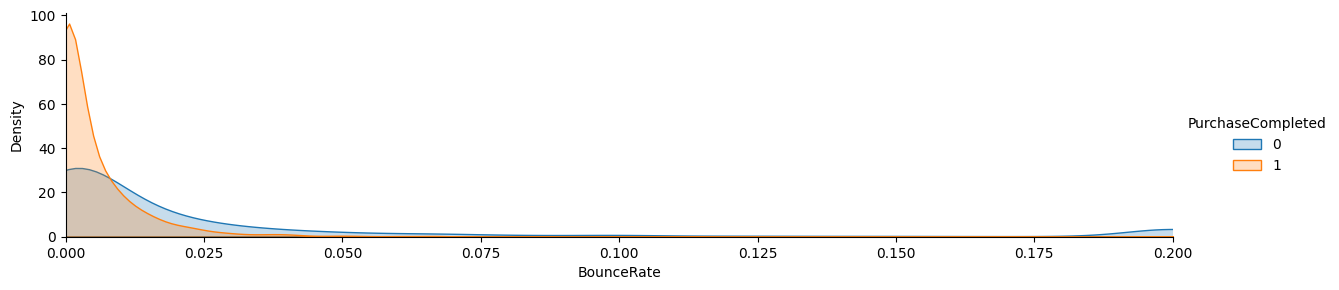

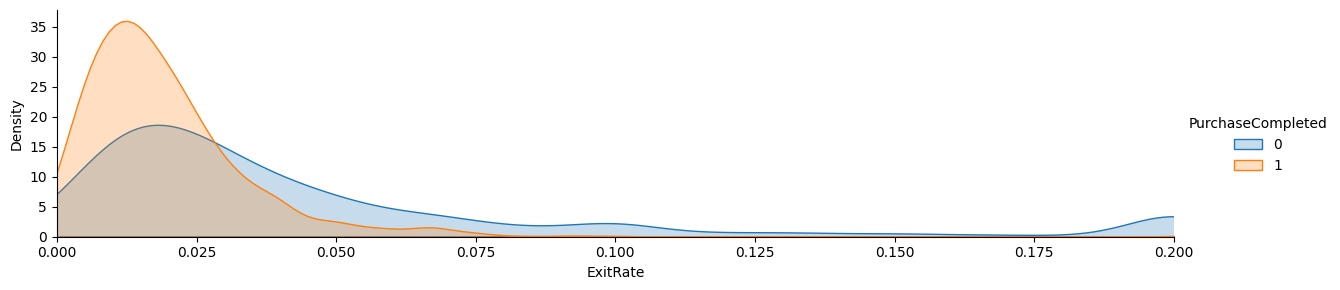

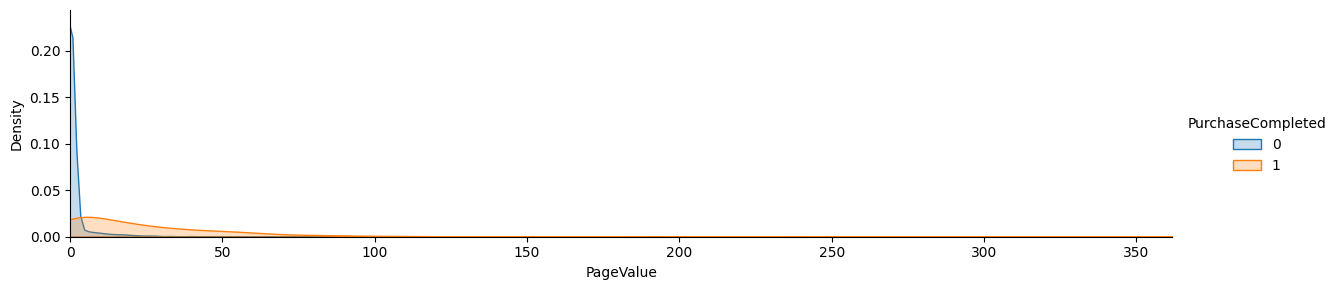

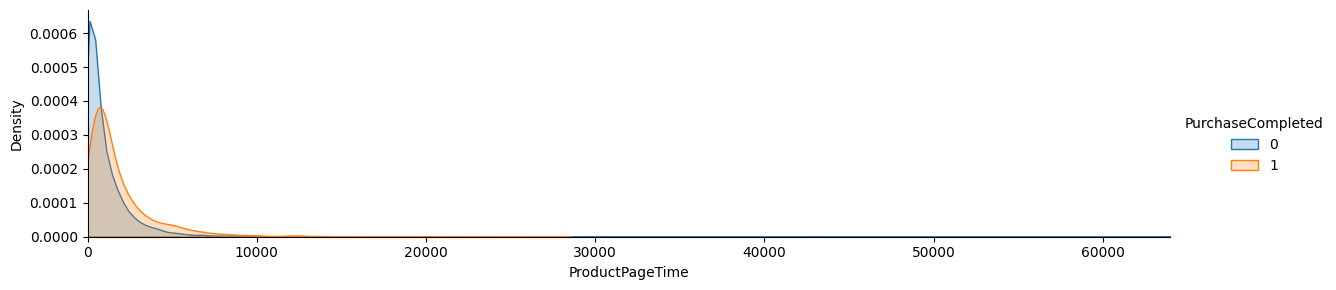

In [ ]:
continuous_features = ["BounceRate", "ExitRate", "PageValue", "ProductPageTime"]

for col in continuous_features:
    facetgridplot(df_cleaned, col)

**Observations**
- Higher probability of PurchaseCompleted=1 for lower BounceRate, lower ExitRate, higher PageValue, and higher ProductPageTime. This is consistent with intuition that users who are more engaged with the website (lower bounce and exit rates, higher page value and time spent) are more likely to complete a purchase.
- However, due to extreme skewness (majority of data points concentrated near 0), no meaningful comparison can be made between the KDE plots at the tail ends.

**Follow-up**
- Replot PageValue to check distribution in the non-zero tail. The 0 value makes up ~78% of the entire distribution (from normalised value counts).

In [ ]:
# Modify KDE plot helper function to exclude values = 0
def facetgridplot_(df, var):
    facet = sns.FacetGrid(df[df[var] != 0], hue="PurchaseCompleted", aspect=4)
    facet.map(sns.kdeplot, var, fill= True)
    facet.set(xlim=(0, df[var].max()))
    facet.add_legend()
    plt.show();

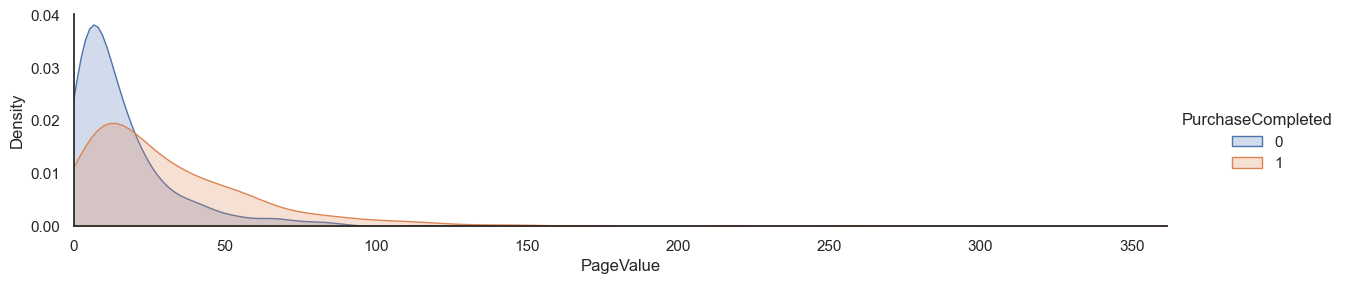

In [345]:
facetgridplot_(df_cleaned, "PageValue")

**Observations**
- Removing the zero-dominated spike (78% of values) reveals that both classes have similar right-skewed distributions, though PurchaseCompleted=1 shows a flatter, wider spread with a heavier tail.
- The visual separation seen in the original plot is primarily driven by the zero vs non-zero split rather than differences in magnitude among non-zero values.
- This suggests a binary has_page_value feature may capture the majority of PageValue's predictive signal, an opportunity for feature engineering.

### Bar Charts

Visualise frequency of categorical variables.

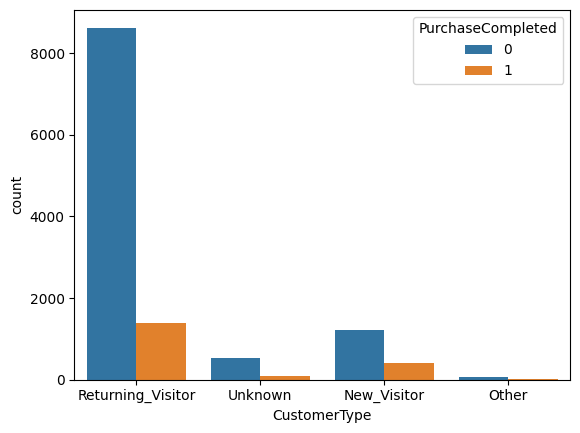

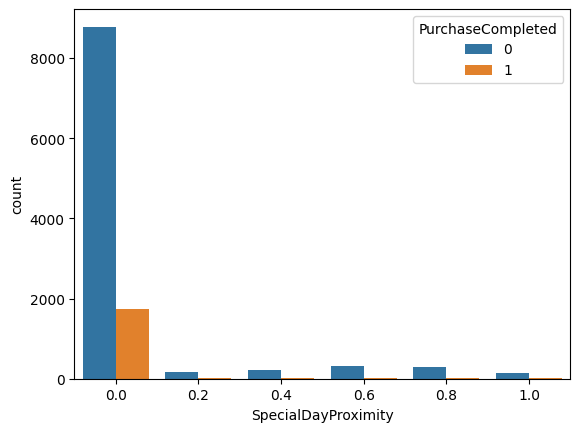

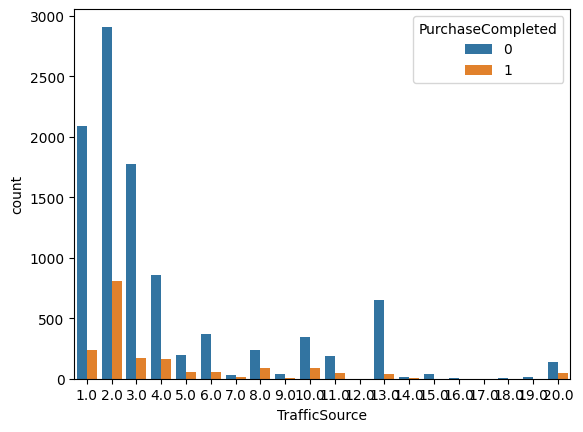

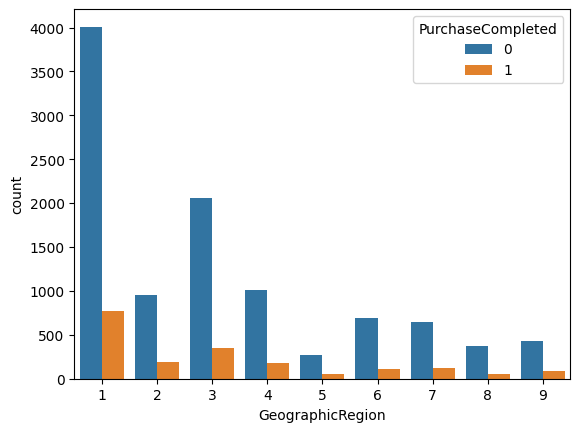

In [ ]:
# Generate bar charts (countplot) for categorical features

categorical_features = ["CustomerType", "SpecialDayProximity", "TrafficSource", "GeographicRegion"]

for col in categorical_features:
    sns.countplot(x=col, hue='PurchaseCompleted', data=df_cleaned)
    plt.show();

**Observations**
- Some classes or group of classes dominate the entire feature:
    - Retuming_Visitor in CustomerType and 0.0 in SpecialDayProxity
    - Traffic sources 1, 2 & 3 dominates the rest.
    - Geographic regions 1 and 3 dominates the rest.
- Need to be cautious when evaluating predictive power of minority classes - small sample size affects statistical reliability.

**Follow-up**
- Also plot normalised stacked bar charts to show category distribution within each target class (each bar sums to 100%) as well as purchase rate bar charts for easy comparison.

In [ ]:
# Helper function for normalised stacked bar chart.
def norm_stacked_bar_chart(df, feature):
    not_completed = df[df['PurchaseCompleted']==0][feature].value_counts(normalize=True)*100
    completed = df[df['PurchaseCompleted']==1][feature].value_counts(normalize=True)*100
    df_normalised = pd.DataFrame([not_completed,completed])
    df_normalised.index = ['0','1']
    df_normalised.plot(kind='bar',stacked=True, figsize=(10,5), colormap='tab20')
    plt.ylabel('Percentage')
    plt.xticks(rotation=0)
    plt.title('Distribution of Categories in Target Label: PurchaseCompleted')
    plt.show();

# Helper function for purchase rate bar chart.
def purchase_rate_bar_chart(df, feature):
    # Order by decreasing frequency in PurchaseCompleted=0 - same as norm_stacked_bar_chart
    order = df[df['PurchaseCompleted']==0][feature].value_counts().index
    purchase_rate = df.groupby(feature)['PurchaseCompleted'].mean().reindex(order)
    purchase_rate.plot(kind='bar', color='steelblue', edgecolor='black', figsize=(6,3))
    plt.ylabel('Purchase Rate')
    plt.title(f'Purchase Rate by {feature}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show();

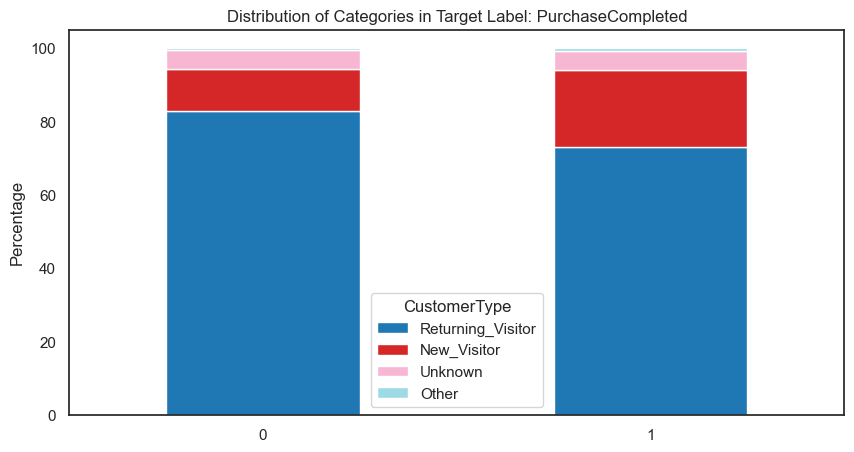

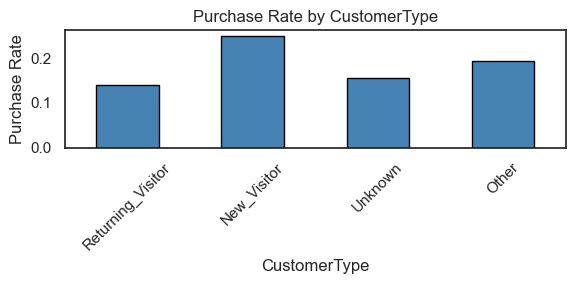

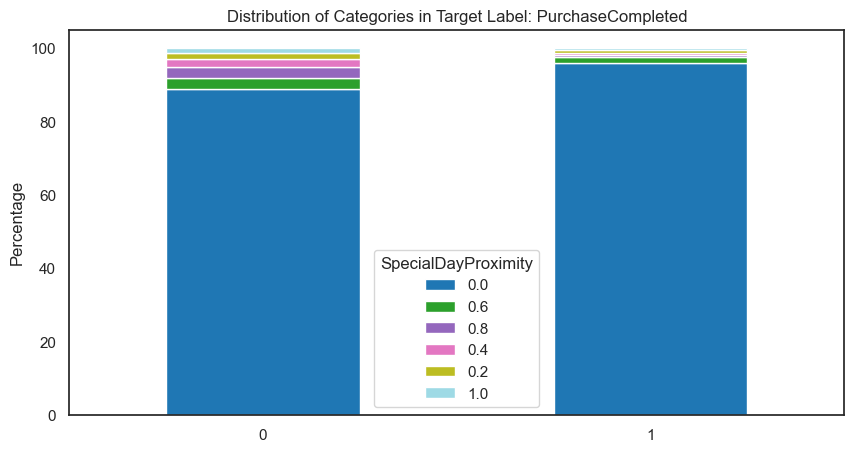

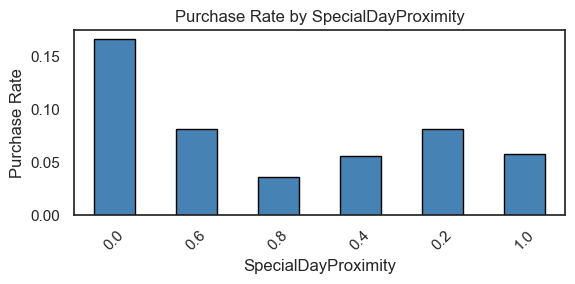

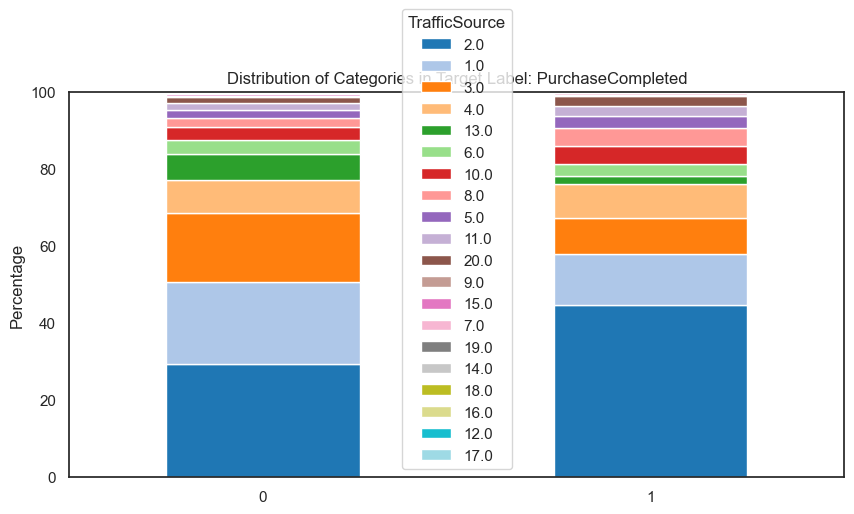

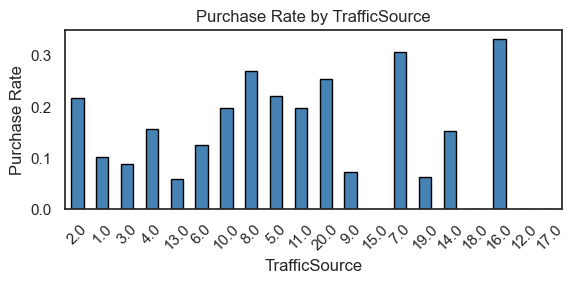

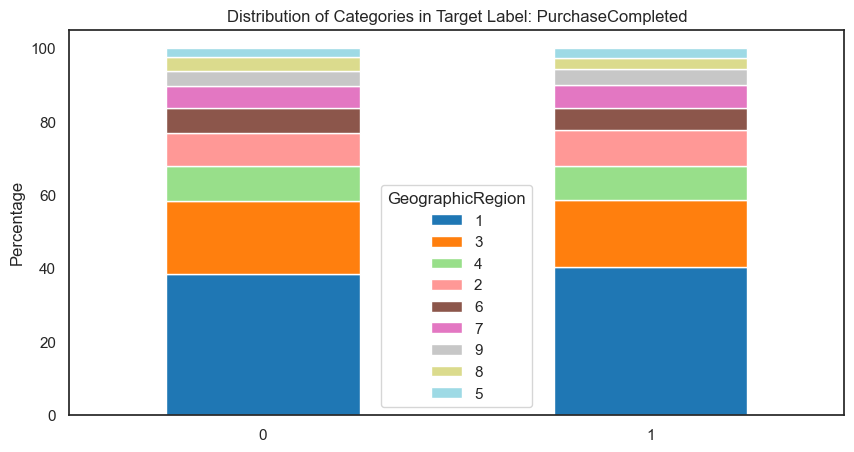

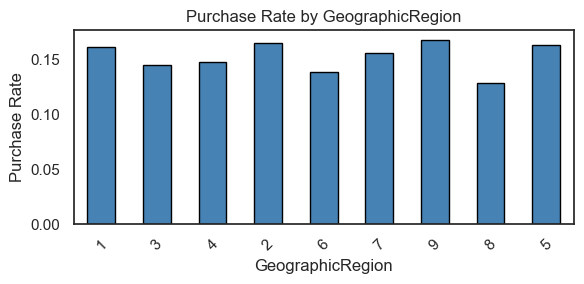

In [363]:
for col in categorical_features:
    norm_stacked_bar_chart(df_cleaned, col)
    purchase_rate_bar_chart(df_cleaned, col)

**Observations**
- CustomerType: New_Visitor more likely to complete purchase than Returning_Visitor.
- SpecialDayProximity: 0.0 (presumably days far away from special days (e.g., holidays)) visitors are more likely to complete purchase than remaining days - which is counter-intuitive as we'd expect days near special days to generate more sales - especially on the special days (SpecialDayProximity = 1.0), which doesn't seem to be the case. Possibly due to low number of data points available.
- TrafficSource: 7 and 16 visitors have the highest purchase rate but have such small number of data points that the bars are not visible in the normalised stacked bar chart. Other notable traffic sources are 2, 5, 8, 10, 11, 20 where visitors are more likely to complete purchase. On the other hand, 12, 15, 17, 18 visitors have a purchase rate of 0, likely due to small number of data points.
- GeographicRegion: Not much variance in the purchase rates within different regions - suggesting low correlation with target variable.

### Box Plot

Check for outliers in continuous variables.

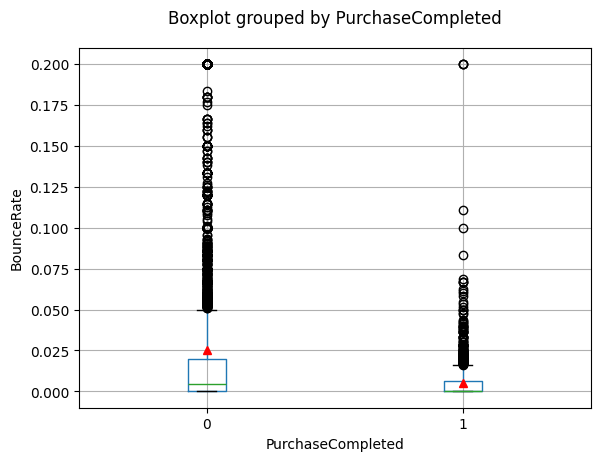

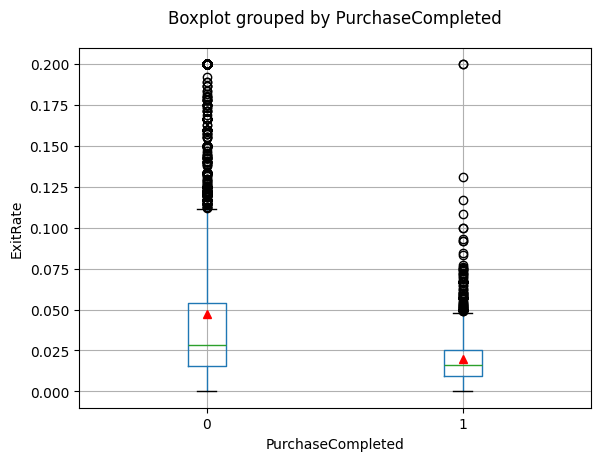

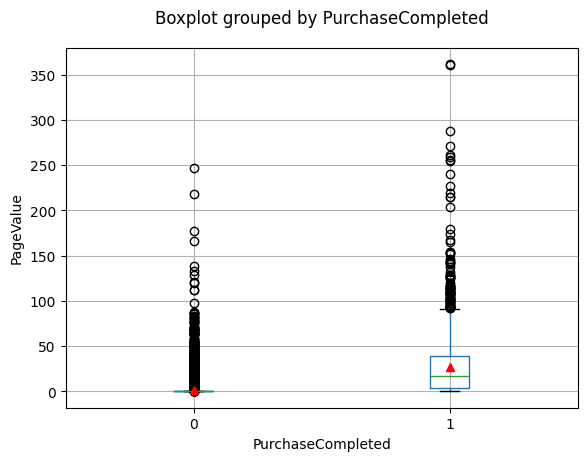

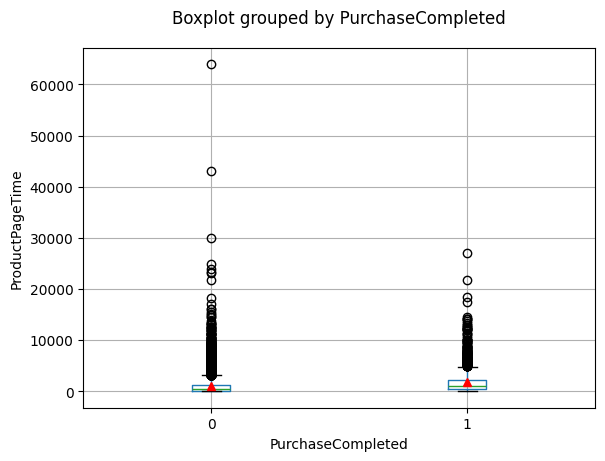

In [190]:
for col in continuous_features:
    df_cleaned.boxplot(column=col, by="PurchaseCompleted", showmeans=True, meanprops={"markerfacecolor":"red", "markeredgecolor":"red"})
    plt.title('')
    plt.ylabel(col)
    plt.show();

**Observations**
- Continuous variables are heavily skewed with majority of data points concentrated near 0 and means (red triangle) > medians (green line).
- Outliers (data points outside whiskers) are abundant. Notable outliers:
    - BounceRate and ExitRate: for PurchaseCompleted=1 boxplot, there is a big gap between the furthest data points (0.20) and the next. But that is fine since we already know that the rates are bounded in the range 0-0.2.
    - PageValue: for PurchaseCompleted=1 boxplot, there is a relatively big gap between furthest data points (~360) and the next (~290). But could still be due to natural variation as there is no known cap to PageValue.
- ProductPageTime: for PurchaseCompleted=1 boxplot, there is a big gap between the furthest data points (~64,000s or 17.8 hours) and the next (~43,000s or 11.9 hours). But could still be due to natural variation - possibly due to visitors leaving their screen on for a long time.

**Follow-up**
- Leave the outliers as is as they may be legitimate due to natural variation. And there is no proof that the outliers are erroneous.
- Impute null values using median instead of mean as they are more representative (not influenced by outliers).
- Feature engineering opportunity to log transform ProductPageTime and PageValue as both are heavily right-skewed with extreme outliers. log(x + 1) compresses the range which can help linear models.

### Correlation Heatmap

Visualise collinearity between continuous variables. Also include:
    - SpecialDayProximity as it is also ordinal
    - CustomerType as it only has few classes - to one-hot encode

Note that null values are automatically excluded.

In [ ]:
# One-hot encode CustomerType
df_corr = pd.get_dummies(df_cleaned[["BounceRate", "ExitRate", "PageValue", "ProductPageTime", "SpecialDayProximity", "CustomerType"]], columns=["CustomerType"], dtype='int')

# Merge with PurchaseCompleted as last column
df_corr = df_corr.merge(df_cleaned[["PurchaseCompleted"]], left_index=True, right_index=True)
df_corr

,BounceRate,ExitRate,PageValue,ProductPageTime,SpecialDayProximity,CustomerType_New_Visitor,CustomerType_Other,CustomerType_Returning_Visitor,CustomerType_Unknown,PurchaseCompleted
0,0.200000,0.200000,0.000000,0.000000,0.0,0,0,1,0,0
1,0.000000,0.100000,0.000000,64.000000,0.0,0,0,1,0,0
2,0.200000,0.200000,0.000000,0.000000,NaN,0,0,1,0,0
3,0.050000,0.140000,0.000000,2.666667,0.0,0,0,1,0,0
4,0.020000,NaN,NaN,627.500000,0.0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
12325,0.007143,0.029031,12.241717,1783.791667,0.0,0,0,1,0,0
12326,0.000000,0.021333,NaN,465.750000,0.0,0,0,1,0,0
12327,0.083333,0.086667,0.000000,184.250000,0.0,0,0,1,0,0
12328,0.000000,0.021053,0.000000,346.000000,0.0,0,0,1,0,0


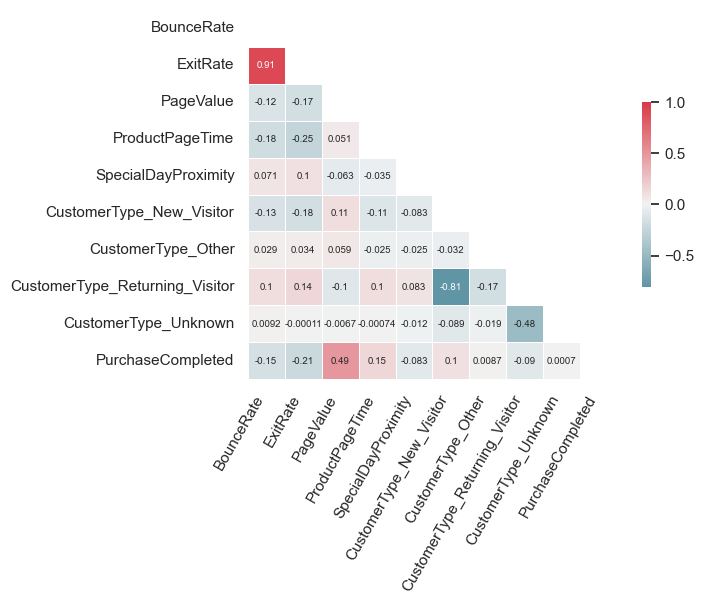

In [ ]:
# Generate correlation heatmap

sns.set_theme(style="white")

# Generate a mask for the upper triangle
mask = np.zeros_like(df_corr.corr(), dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots()

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(df_corr.corr(), mask=mask, cmap=cmap, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True, annot_kws={'fontsize': 7})

ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')

plt.show();

**Observations**
- Strong positive correlation between BounceRate and ExitRate (0.91), which is expected as they are related metrics. Both have weak negative correlation with the target variable PurchaseCompleted.
- PageValue shows a moderate positive correlation with PurchaseCompleted (0.49), indicating that higher page values may be associated with completed purchases, and is the strongest predictor among the features. 
    - PageValue is zero-dominated (~78% of values) with strong predictive power — a binary has_page_value feature may capture the main signal. This reinforces the same findings in the KDE Plot section for a feature engineering opportunity.
- SpecialDayProximity shows a very weak negative correlation with PurchaseCompleted, suggesting that being closer to special days does not significantly influence purchase completion in this dataset.
- Some moderate to strong negative correlation between CustomerType classes is expected as they are related metrics.

## Null Handling

### Null Inspection

In [ ]:
# Number of nulls in each column
df_cleaned.isna().sum()

CustomerType             0
SpecialDayProximity    616
ExitRate               616
PageValue              616
TrafficSource          616
GeographicRegion         0
BounceRate               0
ProductPageTime        616
PurchaseCompleted        0
dtype: int64

In [ ]:
# Check rows with at least one null value
df_cleaned.loc[df_cleaned.isna().any(axis=1)]

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
2,Returning_Visitor,NaN,0.200000,0.000000,3.0,9,0.200000,0.000000,0
4,Returning_Visitor,0.0,NaN,NaN,4.0,1,0.020000,627.500000,0
7,Returning_Visitor,0.0,0.200000,0.000000,5.0,1,0.200000,NaN,0
16,Returning_Visitor,0.0,0.200000,0.000000,3.0,4,0.200000,NaN,0
34,Returning_Visitor,NaN,0.028571,0.000000,1.0,1,0.014286,380.500000,0
...,...,...,...,...,...,...,...,...,...
12297,New_Visitor,0.0,NaN,0.000000,2.0,3,0.033333,139.750000,0
12309,Returning_Visitor,0.0,NaN,0.000000,2.0,1,0.008333,262.900000,0
12310,Returning_Visitor,0.0,NaN,0.000000,3.0,7,0.015789,411.083333,0
12325,Returning_Visitor,0.0,0.029031,12.241717,NaN,1,0.007143,1783.791667,0


In [ ]:
# Check distribution of number of nulls in rows
df_cleaned.isna().sum(axis=1).value_counts()

0    9552
1    2493
2     268
3      17
Name: count, dtype: int64

**Observations**
- Same number of null values (616) in "SpecialDayProximity", "ExitRate", "PageValue", "TrafficSource" and "ProductPageTime" suggesting systematic data quality issues (data collection/ETL failure). The number 616 also coincides with other issues as identified previously:
    - CustomerType: total number of "", "nan", "None", "Unknown" = 166 + 153 + 153 + 144 = 616
    - GeographicRegion: total number of negative categories = 23 + 21 + 37 + 33 + 21 + 59 + 120 + 58 + 244 = 616
- However, the distribution of these 4 * 616 null values is spread out across 2778 rows, with most rows containing only 1 null value. This suggests that the null values in the 4 columns may not be related.

In [200]:
# Check how many nulls are in each entry of the "", "nan", "None", "Unknown" categories for CustomerType
df[(df.CustomerType == "") | (df.CustomerType == "nan") | (df.CustomerType == "None") | (df.CustomerType == "Unknown")].isna().sum(axis=1).value_counts()

0    490
1    118
2      8
Name: count, dtype: int64

In [201]:
# Check how many nulls are in each entry of the negative GeographicRegion entries
df[df.GeographicRegion < 0].isna().sum(axis=1).value_counts()

0    488
1    113
2     15
Name: count, dtype: int64

**Observations**
- Most of the rows in the problematic "CustomerType" and "GeographicRegion" entries do not contain any nulls.
- This suggests that the issues are independent data quality issue and not part of the same systematic problem.
- On the contrary, the 616 number may just the dataset creator's chosen number for injecting different types of messiness.

**Follow-up**
- Impute null values with median/mode rather than dropping them, because:
    - Losing 22.5% of data is significant (12,330 → 9,552).
    - Most affected rows (2,493 of 2,778) are only missing 1 value — dropping entire rows for a single missing field is wasteful.

In [238]:
df_cleaned.describe(include="all")

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
count,12330,11714.000000,11714.000000,11714.000000,11714.000000,12330.000000,12330.000000,11714.000000,12330.000000
unique,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Returning_Visitor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,10026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.060833,0.043058,5.906249,4.059501,3.147364,0.022191,1198.724243,0.154745
std,NaN,0.197459,0.048506,18.682351,4.015758,2.401591,0.048488,1928.855727,0.361676
min,NaN,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,NaN,0.000000,0.014286,0.000000,2.000000,1.000000,0.000000,184.270833,0.000000
50%,NaN,0.000000,0.025286,0.000000,2.000000,3.000000,0.003112,602.958333,0.000000
75%,NaN,0.000000,0.050000,0.000000,4.000000,4.000000,0.016813,1465.955181,0.000000


### Imputing Strategy

In [ ]:
# Check mean
df_cleaned[["SpecialDayProximity", "ExitRate", "PageValue", "TrafficSource", "ProductPageTime"]].mean()

SpecialDayProximity       0.060833
ExitRate                  0.043058
PageValue                 5.906249
TrafficSource             4.059501
ProductPageTime        1198.724243
dtype: float64

In [ ]:
# Check median
df_cleaned[["SpecialDayProximity", "ExitRate", "PageValue", "TrafficSource", "ProductPageTime"]].median()

SpecialDayProximity      0.000000
ExitRate                 0.025286
PageValue                0.000000
TrafficSource            2.000000
ProductPageTime        602.958333
dtype: float64

In [ ]:
# Check mode
df_cleaned[["SpecialDayProximity", "ExitRate", "PageValue", "TrafficSource", "ProductPageTime"]].mode()

,SpecialDayProximity,ExitRate,PageValue,TrafficSource,ProductPageTime
0,0.0,0.2,0.0,2.0,0.0


**Imputing Strategy**
- SpecialDayProximity (categorical): Both median and mode has the same value of 0, and the 0 class makes up ~90% of the entire distribution (from normalised value counts). Safe to impute nulls to 0.
- ExitRate (continuous): Impute nulls using median instead of mean as mentioned in boxplot section due to skewness and outliers.
- PageValue (continuous): Both median and mode has the same value of 0, and the 0 value makes up ~78% of the entire distribution (from normalised value counts). Safe to impute nulls to 0.
- TrafficSource (categorical): Possibly impute to mode of 2.0 - but this will inflate the category by 616 (3718 > 4334). Alternative is to create a new class (21.0) as an unknown category. To explore
- ProductPageTime (continuous): Possibly impute nulls using median value of ~603 instead of mean (~1199) as mentioned in boxplot section due to skewness and outliers. But with a large variance (std ~1929 from statistical summary above), there is an opportunity to impute using a stratified median based on other features like CustomerType. To explore.

In [ ]:
# Check PurchaseCompleted rate for the null TrafficSource category
df_cleaned.groupby('TrafficSource', dropna=False)["PurchaseCompleted"].mean().sort_values(ascending=False)

TrafficSource
16.0    0.333333
7.0     0.307692
8.0     0.271028
20.0    0.255319
5.0     0.221344
2.0     0.217052
10.0    0.199063
11.0    0.198276
4.0     0.156342
NaN     0.155844
14.0    0.153846
6.0     0.125891
1.0     0.102828
3.0     0.087692
9.0     0.073171
19.0    0.062500
13.0    0.058993
12.0    0.000000
15.0    0.000000
17.0    0.000000
18.0    0.000000
Name: PurchaseCompleted, dtype: float64

**Observations**
- The NaN PurchaseCompleted rate of ~15.6% is almost exactly the overall dataset mean (~15.5%). This suggests the missing TrafficSource values are not biased toward any particular traffic behavior — they look like a random sample of the population.
- This supports median/mode imputation (class 2.0) over creating a new "Unknown" class.

In [264]:
# Check median ProductPageTime for each CustomerType
df_cleaned.groupby('CustomerType')['ProductPageTime'].median().sort_values(ascending=False)

CustomerType
Returning_Visitor    664.800000
Unknown              581.083333
New_Visitor          407.833333
Other                179.437500
Name: ProductPageTime, dtype: float64

In [369]:
# Check distribution of CustomerType in affected ProductPageTime null entries
df_cleaned[df_cleaned["ProductPageTime"].isna()]["CustomerType"].value_counts()

CustomerType
Returning_Visitor    506
New_Visitor           78
Unknown               27
Other                  5
Name: count, dtype: int64

**Observations**
- There is meaningful differences between the median ProductPageTime among the customer types. Returning_Visitor median (~665) is ~3.7x Other (~179) and ~1.6x New_Visitor (408).
- Imputing the null ProductPageTime values based on this stratified median values (by CustomerType) would be more accurate compared to just using the global median value of ~603.

### Null Imputation

In [ ]:
df_fillna = df_cleaned.copy()
df_fillna['SpecialDayProximity'] = df_fillna['SpecialDayProximity'].fillna(0)
df_fillna['ExitRate'] = df_fillna['ExitRate'].fillna(df_fillna['ExitRate'].median())
df_fillna['PageValue'] = df_fillna['PageValue'].fillna(0)
df_fillna['TrafficSource'] = df_fillna['TrafficSource'].fillna(df_fillna['TrafficSource'].mode()[0])
df_fillna["ProductPageTime"] = df_fillna["ProductPageTime"].fillna(df_fillna.groupby("CustomerType")["ProductPageTime"].transform("median"))
df_fillna

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
0,Returning_Visitor,0.0,0.200000,0.000000,1.0,1,0.200000,0.000000,0
1,Returning_Visitor,0.0,0.100000,0.000000,2.0,1,0.000000,64.000000,0
2,Returning_Visitor,0.0,0.200000,0.000000,3.0,9,0.200000,0.000000,0
3,Returning_Visitor,0.0,0.140000,0.000000,4.0,2,0.050000,2.666667,0
4,Returning_Visitor,0.0,0.025286,0.000000,4.0,1,0.020000,627.500000,0
...,...,...,...,...,...,...,...,...,...
12325,Returning_Visitor,0.0,0.029031,12.241717,2.0,1,0.007143,1783.791667,0
12326,Returning_Visitor,0.0,0.021333,0.000000,8.0,1,0.000000,465.750000,0
12327,Returning_Visitor,0.0,0.086667,0.000000,13.0,1,0.083333,184.250000,0
12328,Returning_Visitor,0.0,0.021053,0.000000,11.0,3,0.000000,346.000000,0


In [279]:
df_fillna.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerType         12330 non-null  str    
 1   SpecialDayProximity  12330 non-null  float64
 2   ExitRate             12330 non-null  float64
 3   PageValue            12330 non-null  float64
 4   TrafficSource        12330 non-null  float64
 5   GeographicRegion     12330 non-null  int64  
 6   BounceRate           12330 non-null  float64
 7   ProductPageTime      12330 non-null  float64
 8   PurchaseCompleted    12330 non-null  int64  
dtypes: float64(6), int64(2), str(1)
memory usage: 867.1 KB


In [278]:
df_fillna.describe(include="all")

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
count,12330,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
unique,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Returning_Visitor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,10026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.057794,0.042170,5.611176,3.956610,3.147364,0.022191,1170.043959,0.154745
std,NaN,0.192919,0.047437,18.255063,3.939787,2.401591,0.048488,1884.326760,0.361676
min,NaN,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,NaN,0.000000,0.014669,0.000000,2.000000,1.000000,0.000000,199.162500,0.000000
50%,NaN,0.000000,0.025286,0.000000,2.000000,3.000000,0.003112,644.225000,0.000000
75%,NaN,0.000000,0.047222,0.000000,4.000000,4.000000,0.016813,1391.313889,0.000000


**Observations**
- Verified successful imputation of nulls.
- Means of SpecialDayProximity, ExitRate, PageValue and ProductPageTime	reduced as expected since they are all right-skewed and we performed a median impute.
- Similarly, the medians are unchanged as expected, except for ProductPageTime which increased slightly due to the stratified median imputation by CustomerType	- imputed entries were mostly Returning_Visitor which had a higher median (~665) than the original global median (~603).

In [304]:
# Check number of duplicates after filling nulls
print("Number of duplicates except first occurrence:", df_fillna.duplicated().sum())
print("Number of duplicates including first occurrence:", df_fillna.duplicated(keep=False).sum())

Number of duplicates except first occurrence: 485
Number of duplicates including first occurrence: 587


**Observations**
- Number of duplicates increased:
    - Number of duplicates except first occurrence: 433 > 485
    - Number of duplicates including first occurrence: 536 > 587
- 51 more duplicates were added which is expected as the imputation process will naturally produce some duplicates (imputing null values with median/mode values naturally creates more identical rows). Not a systematic issue as the imputation affected much more entries (2778 entries).

In [327]:
# Generate a version with nulls dropped for comparison
df_dropped = df_cleaned.dropna()

# Check class balance (rate of PurchaseCompleted)
print("Imputed:", df_fillna['PurchaseCompleted'].mean())
print("Dropped:", df_dropped['PurchaseCompleted'].mean())

Imputed: 0.15474452554744525
Dropped: 0.15577889447236182


**Observations**
- Purchase rate is nearly identical between imputed (15.47%) and dropped (15.58%) datasets, confirming that null values are Missing Completely At Random (MCAR) and imputation does not introduce target bias."

In [ ]:
# Save filled data to CSV
df_fillna.to_csv("data/online_shopping_fillna.csv", index=False)

## Regenerate Visualisations

Regenerate only the plots affected by imputation: 
- KDE Plot for ExitRate PageValue, and ProductPageTime (PageValue KDE Plot (excluding zeros) is not meaningful as we imputed with the value 0 - the plot will be identical to before imputation)
- Bar Charts for SpecialDayProximity and TrafficSource
- Box Plots for ExitRate, PageValue, and ProductPageTime
- Correlation Heatmap

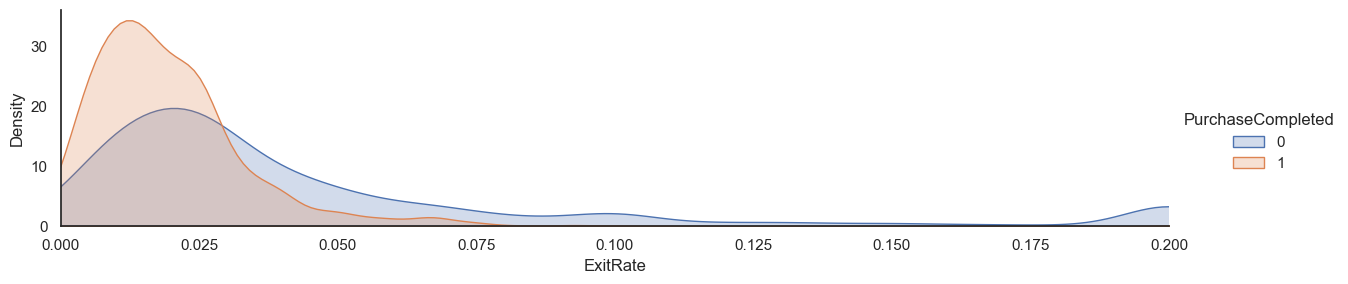

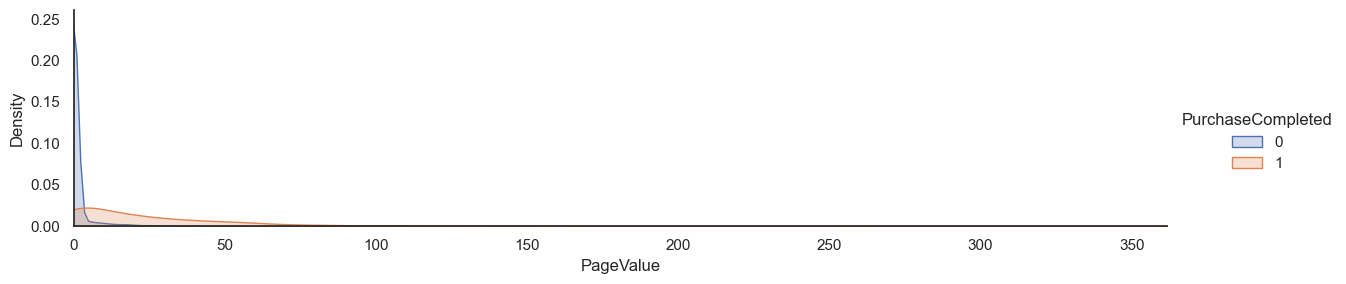

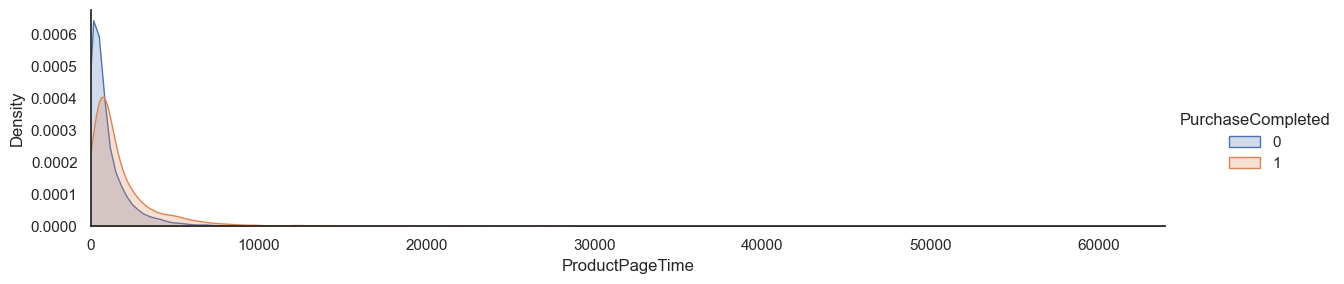

In [366]:
# Regenerate KDE Plots for affected columns

for col in ["ExitRate", "PageValue", "ProductPageTime"]:
    facetgridplot(df_fillna, col)

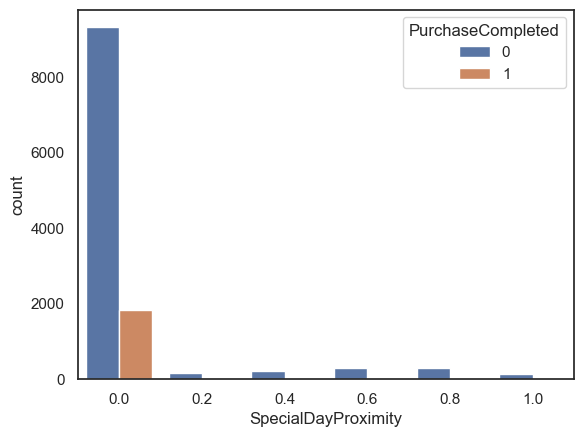

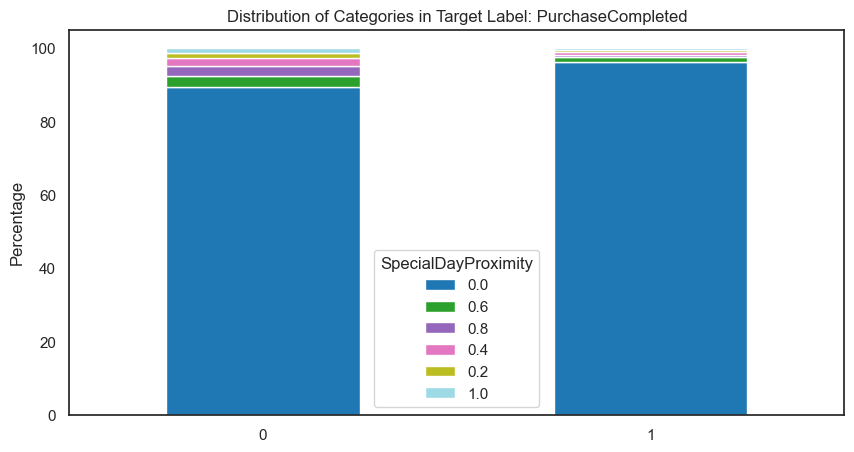

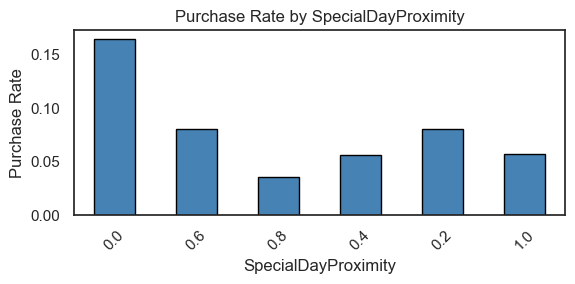

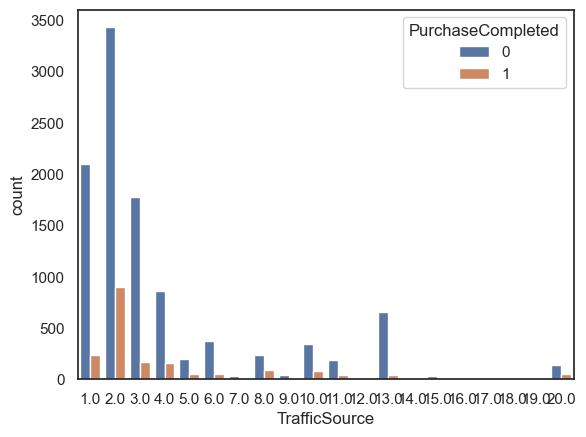

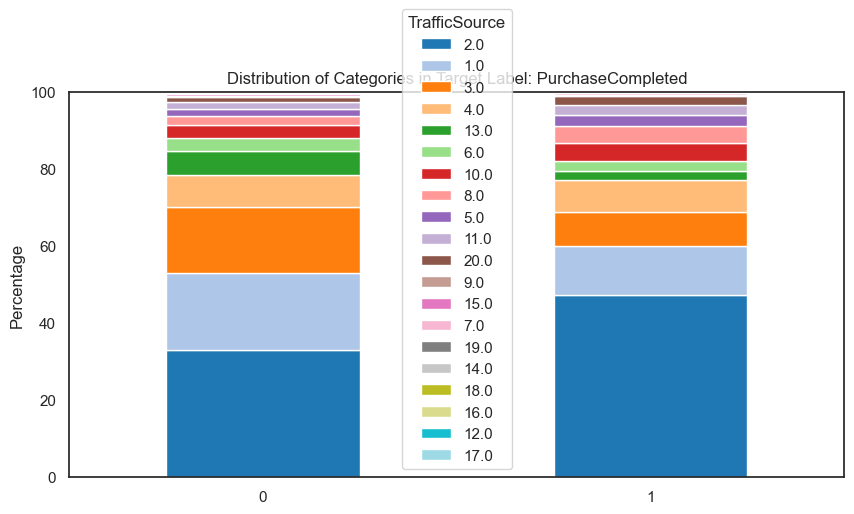

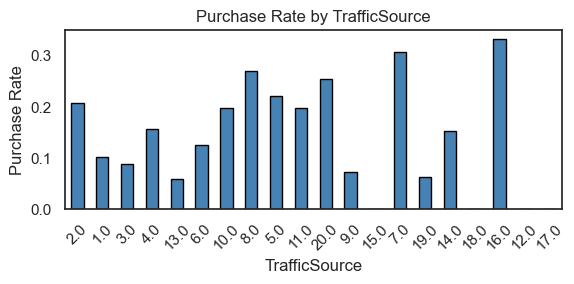

In [374]:
# Regenerate Bar Charts for affected columns

for col in ["SpecialDayProximity", "TrafficSource"]:
    sns.countplot(x=col, hue='PurchaseCompleted', data=df_fillna)
    plt.show();

    norm_stacked_bar_chart(df_fillna, col)
    purchase_rate_bar_chart(df_fillna, col)

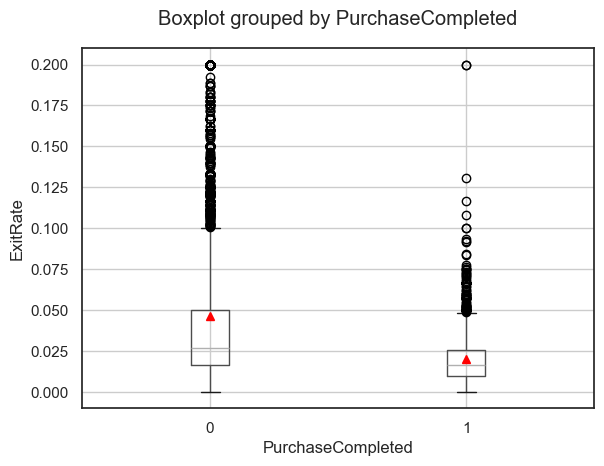

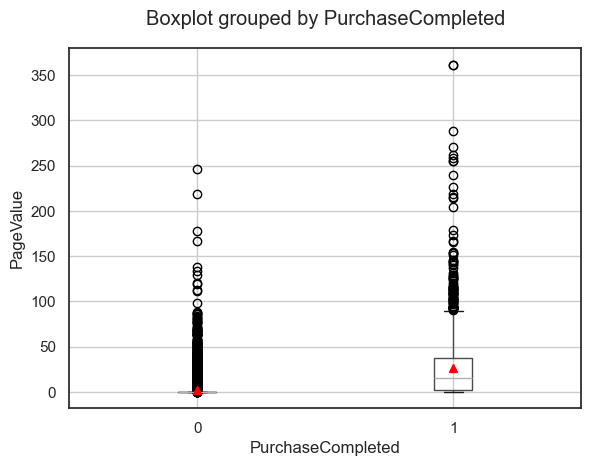

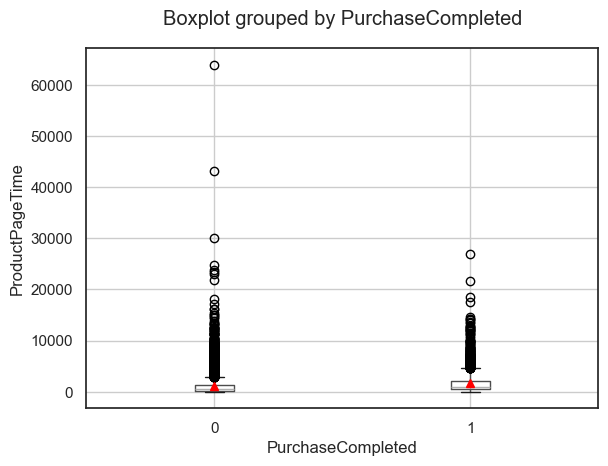

In [ ]:
# Regenerate Boxplots for affected columns

for col in ["ExitRate", "PageValue", "ProductPageTime"]:
    df_fillna.boxplot(column=col, by="PurchaseCompleted", showmeans=True, meanprops={"markerfacecolor":"red", "markeredgecolor":"red"})
    plt.title('')
    plt.ylabel(col)
    plt.show();

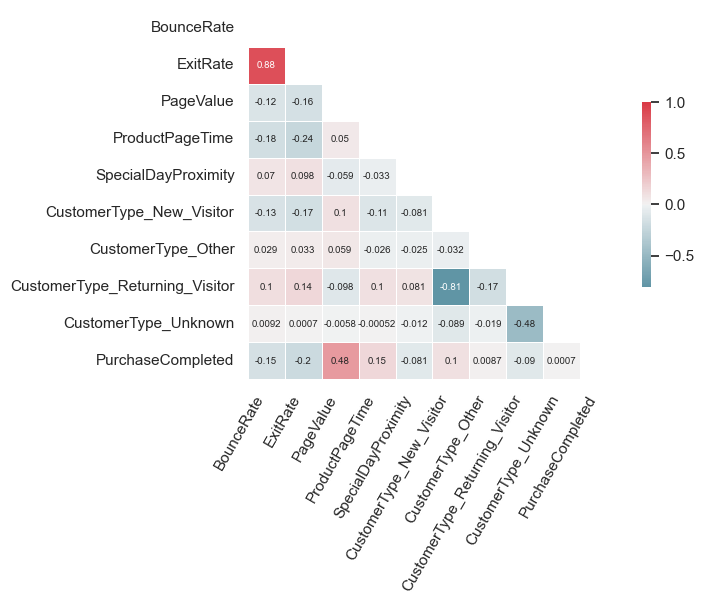

In [312]:
# One-hot encode CustomerType
df_corr = pd.get_dummies(df_fillna[["BounceRate", "ExitRate", "PageValue", "ProductPageTime", "SpecialDayProximity", "CustomerType"]], columns=["CustomerType"], dtype='int')

# Merge with PurchaseCompleted as last column
df_corr = df_corr.merge(df_fillna[["PurchaseCompleted"]], left_index=True, right_index=True)

# Generate correlation heatmap

sns.set_theme(style="white")

# Generate a mask for the upper triangle
mask = np.zeros_like(df_corr.corr(), dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots()

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(df_corr.corr(), mask=mask, cmap=cmap, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True, annot_kws={'fontsize': 7})

ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')

plt.show();

**Observations**
- KDE plots for ExitRate and ProductPageTime retain the same directional patterns (lower ExitRate and higher ProductPageTime associated with PurchaseCompleted=1). Median imputation slightly sharpens the peaks near the median values, reinforcing central tendency without introducing new distributional features. 
- KDE plot for PageValue sharpened at the value 0 as expected since we imputed using the median value of 0.
- SpecialDayProximity box plots: Imputing nulls to 0.0 further inflates the already dominant 0.0 class. Purchase rate of class 0.0 appear unchanged.
- TrafficSource box plots: Imputing nulls to mode (2.0) inflates class 2 (3718 → 4334). Purchase rate for class 2 reduced slightly.
- Boxplots for ExitRate, PageValue and ProductPageTime show no new outliers introduced by imputation as expected. Median lines and IQR ranges remain consistent with pre-imputation plots.
- Correlation structure is preserved — no meaningful changes to correlation coefficients.

# Misc

In [340]:
# Sanity check for suspicious/impossible combination - PageValue > 0 but ProductPageTime = 0, which should be impossible as PageValue is derived from products viewed and time spent on product pages.

((df_fillna['ProductPageTime'] == 0) & (df_fillna['PageValue'] > 0)).sum()

np.int64(0)

**Observations**
- No such values. Good.

# End of Notebook